# Import Correlation Matrices
Load all correlation matrices from the shifted Pearson correlation matrices folder

In [1]:
import pandas as pd
import os
from pathlib import Path

# Define the path to the shifted Pearson correlation matrices folder
matrices_folder = 'correlation_matrices_session_shifted_average'

# Load all session-average shifted Pearson correlation matrices
correlation_matrices = {}
for filename in sorted(os.listdir(matrices_folder)):
    if filename.endswith('_avg_shifted_pearson_corr.csv'):
        file_path = os.path.join(matrices_folder, filename)
        # Extract subject and session info from filename
        subject_session = filename.replace('_avg_shifted_pearson_corr.csv', '')
        correlation_matrices[subject_session] = pd.read_csv(file_path, index_col=0)

print(f"Loaded {len(correlation_matrices)} correlation matrices")
print("Subjects loaded:", list(correlation_matrices.keys())[:5], "...")

Loaded 125 correlation matrices
Subjects loaded: ['sub-NORB00001_ses-1', 'sub-NORB00003_ses-1', 'sub-NORB00005_ses-1', 'sub-NORB00006_ses-1', 'sub-NORB00007_ses-1'] ...


## Calculate Jaccard Index (Min/Max Formula) for All Edge Pairs
For each edge pair (e.g., F3-PZ), calculate the Jaccard index between all pairs of subject-sessions using: J(A,B) = min(A,B) / max(A,B)

In [2]:
import numpy as np
from itertools import combinations

# Get all unique edge pairs from the first correlation matrix
first_matrix = list(correlation_matrices.values())[0]
edge_pairs = list(combinations(first_matrix.index, 2))
print(f"Total unique edge pairs: {len(edge_pairs)}")
print(f"Sample edge pairs: {edge_pairs[:5]}")

# Calculate Jaccard index for all edge pairs between all subject-session pairs
subject_sessions = list(correlation_matrices.keys())
num_subjects = len(subject_sessions)

# Create a dictionary to store Jaccard indices for each edge pair
jaccard_indices = {}

for edge_pair in edge_pairs:
    region1, region2 = edge_pair
    # Extract correlation values for this edge pair across all subject-sessions
    edge_values = {}
    for subject_session, matrix in correlation_matrices.items():
        if region1 in matrix.index and region2 in matrix.columns:
            edge_values[subject_session] = matrix.loc[region1, region2]
    
    # Calculate Jaccard index (min/max) between all pairs of subject-sessions
    jaccard_for_edge = {}
    for subject_pair in combinations(subject_sessions, 2):
        ss1, ss2 = subject_pair
        val1 = edge_values.get(ss1)
        val2 = edge_values.get(ss2)
        
        if val1 is not None and val2 is not None:
            # Jaccard index using min/max formula
            jaccard_idx = min(val1, val2) / max(val1, val2) if max(val1, val2) != 0 else 0
            jaccard_for_edge[subject_pair] = jaccard_idx
    
    jaccard_indices[edge_pair] = jaccard_for_edge

print(f"\nCalculated Jaccard indices for {len(jaccard_indices)} edge pairs")
print(f"Number of subject-session pairs: {len(list(combinations(subject_sessions, 2)))}")
print(f"Sample Jaccard values for first edge pair {edge_pairs[0]}: {list(list(jaccard_indices.values())[0].items())[:3]}")

Total unique edge pairs: 171
Sample edge pairs: [('Fp1', 'Fp2'), ('Fp1', 'F3'), ('Fp1', 'F4'), ('Fp1', 'C3'), ('Fp1', 'C4')]

Calculated Jaccard indices for 171 edge pairs
Number of subject-session pairs: 7750
Sample Jaccard values for first edge pair ('Fp1', 'Fp2'): [(('sub-NORB00001_ses-1', 'sub-NORB00003_ses-1'), np.float64(0.9824358742138918)), (('sub-NORB00001_ses-1', 'sub-NORB00005_ses-1'), np.float64(0.9817181383705265)), (('sub-NORB00001_ses-1', 'sub-NORB00006_ses-1'), np.float64(0.9583891904290212))]


## Session 1 Jaccard Index Heatmap for Multi-Session Subjects
Create a heatmap comparing Session 1 Jaccard indices between subject pairs that both have multiple sessions


Heatmap shape: (210, 171)
Valid subject pairs used: 210
Smallest age difference: 0.0000
Largest age difference: 0.2070


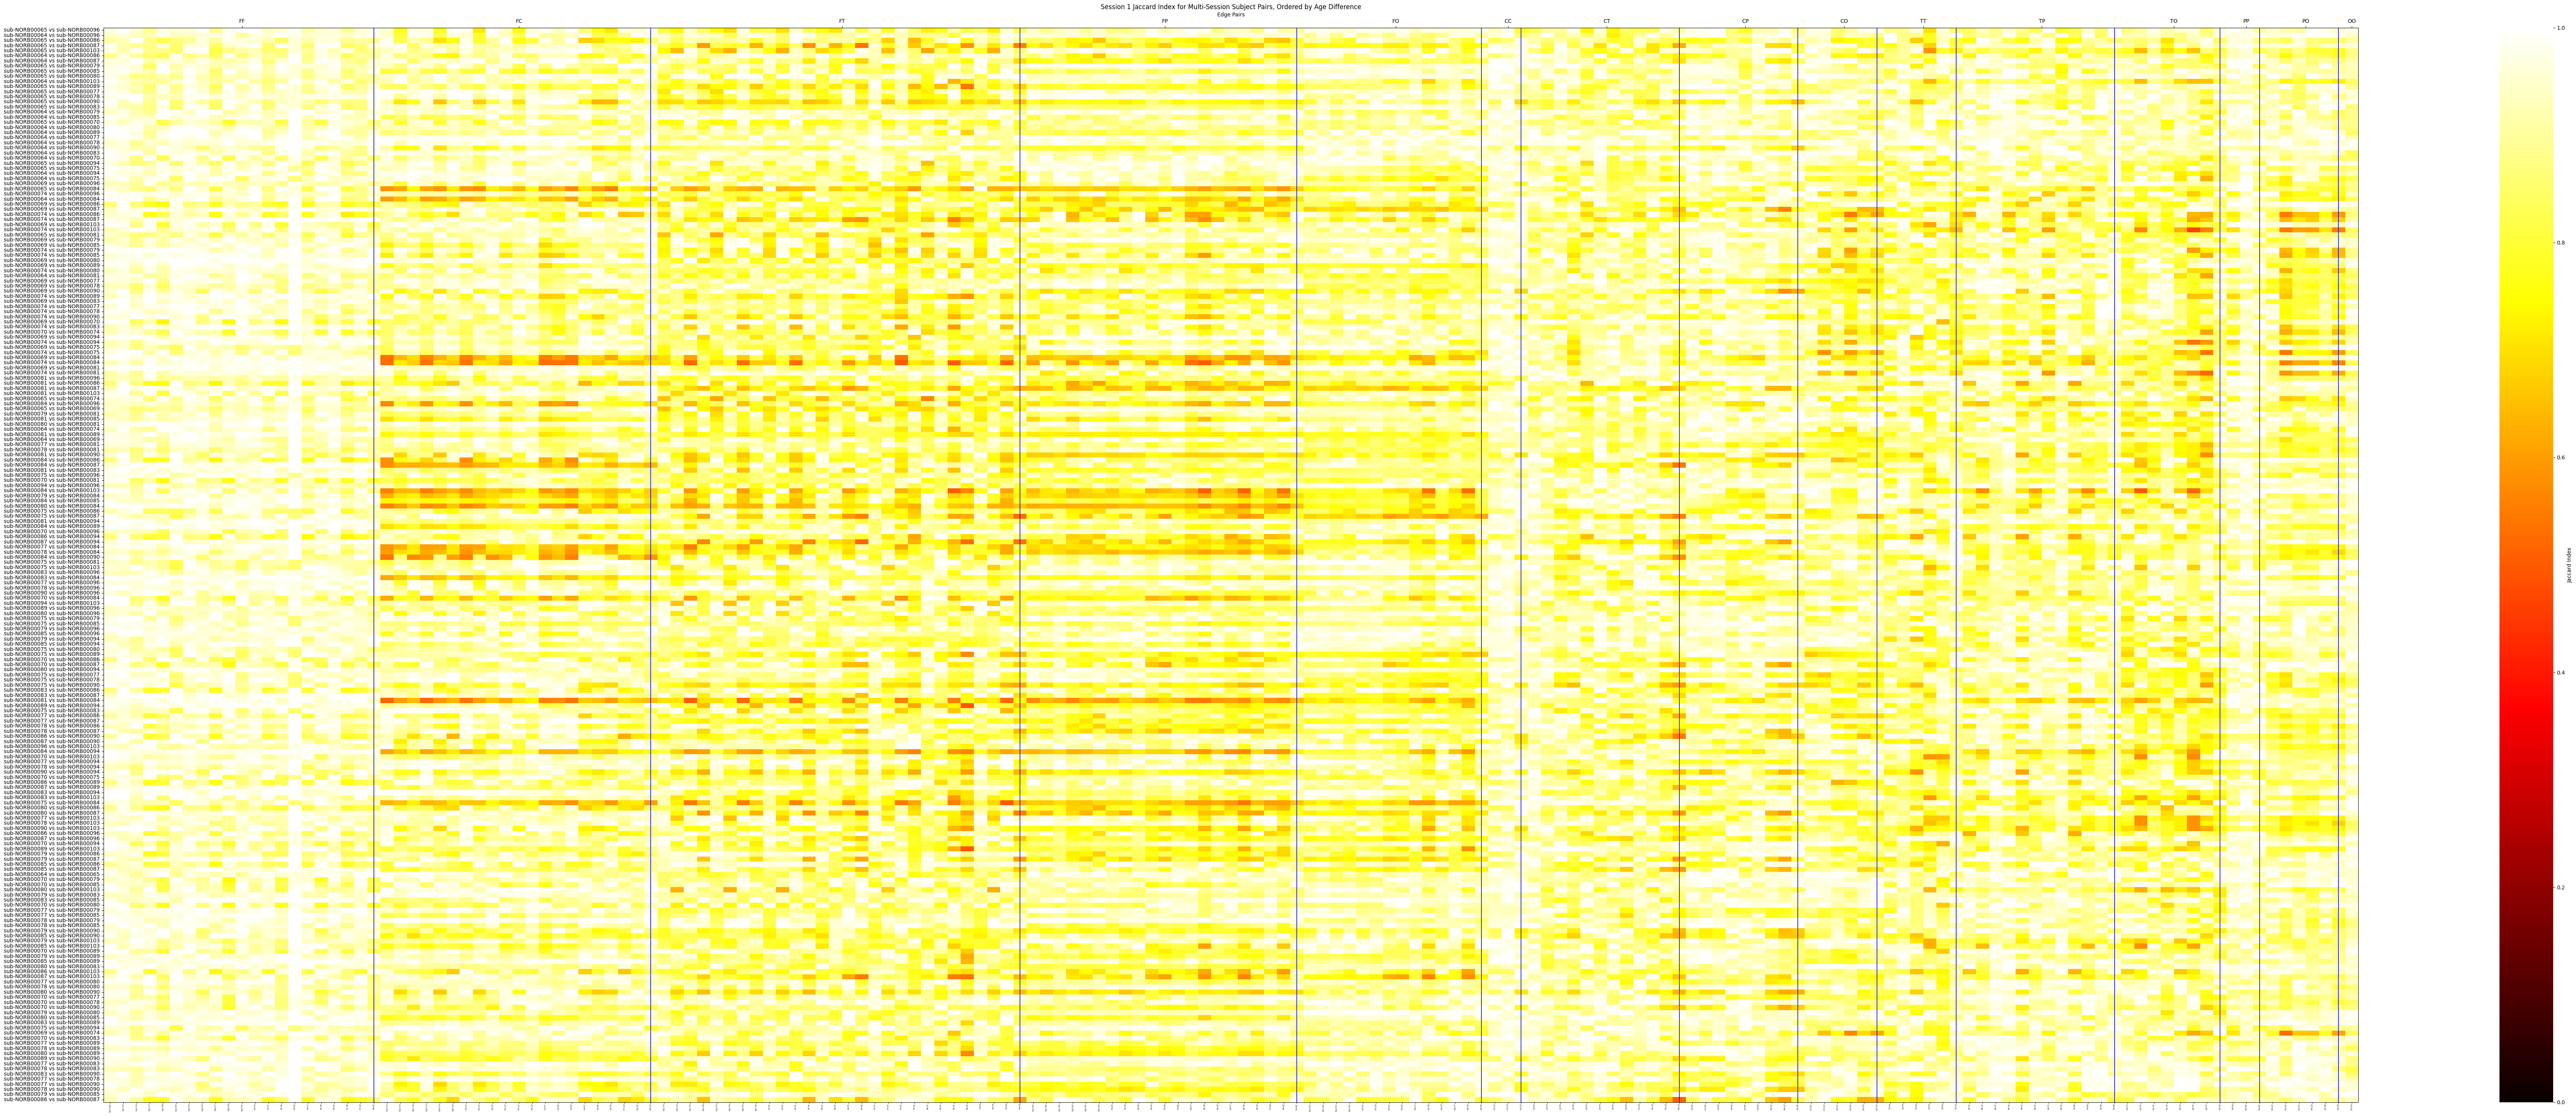

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

age_df = pd.read_csv('age_acq_time_sorted.csv')
age_lookup = dict(zip(age_df['label'], age_df['age_acq_time']))

subject_sessions_dict = defaultdict(list)
for ss in subject_sessions:
    subject_id, session = ss.split('_ses-')
    subject_sessions_dict[subject_id].append(int(session))

multi_session_subjects = [subj for subj, sessions in subject_sessions_dict.items() if len(sessions) > 1]
session1_keys = {f'{subj}_ses-1' for subj in multi_session_subjects}

valid_session1 = {k for k in session1_keys if k in subject_sessions and k in age_lookup}
pairs = list(combinations(sorted(s.replace('_ses-1', '') for s in valid_session1), 2))

band_order = 'FCTPO'
order_keys = [a + b for i, a in enumerate(band_order) for b in band_order[i:]]
order_map = {k: i for i, k in enumerate(order_keys)}

def band_key(edge):
    a, b = edge
    return ''.join(sorted((a[0].upper(), b[0].upper()),
                          key=lambda c: band_order.index(c)))

sorted_edge_pairs = sorted(edge_pairs, key=lambda ep: order_map[band_key(ep)])

session1_pairs_by_age = []
for sub1, sub2 in pairs:
    ss1, ss2 = f'{sub1}_ses-1', f'{sub2}_ses-1'
    age_diff = abs(age_lookup[ss1] - age_lookup[ss2])

    values = [
        jaccard_indices[edge].get((ss1, ss2),
            jaccard_indices[edge].get((ss2, ss1), np.nan))
        for edge in sorted_edge_pairs
    ]

    if not np.isnan(values).all():
        session1_pairs_by_age.append({
            'pair_label': f'{sub1} vs {sub2}',
            'age_difference': age_diff,
            'values': values,
        })

sorted_valid_pairs = sorted(session1_pairs_by_age, key=lambda item: item['age_difference'], reverse=True)

heatmap_df = pd.DataFrame(
    [item['values'] for item in sorted_valid_pairs],
    index=[item['pair_label'] for item in sorted_valid_pairs],
    columns=[f'{a}-{b}' for a, b in sorted_edge_pairs],
)

print(f"\nHeatmap shape: {heatmap_df.shape}")
print(f"Valid subject pairs used: {len(heatmap_df)}")
if not heatmap_df.empty:
    print(f"Smallest age difference: {sorted_valid_pairs[-1]['age_difference']:.4f}")
    print(f"Largest age difference: {sorted_valid_pairs[0]['age_difference']:.4f}")

fig_width = max(72, len(heatmap_df.columns) * 0.45)
fig_height = max(18, len(heatmap_df.index) * 0.14)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    heatmap_df,
    cmap='hot',
    cbar_kws={'label': 'Jaccard Index'},
    vmin=0,
    vmax=1,
    ax=ax,
    xticklabels=False,
    yticklabels=True,
 )
ax.set_xticks(np.arange(len(heatmap_df.columns)) + 0.5)
ax.set_xticklabels(heatmap_df.columns, rotation=90, fontsize=4)
ax.tick_params(axis='x', which='both', length=2, pad=1)

col_band_keys = [band_key(ep) for ep in sorted_edge_pairs]
unique_band_keys = [k for k in order_keys if k in col_band_keys]

group_positions = []
group_labels = []
group_boundaries = []
for key in unique_band_keys:
    indices = [i for i, k in enumerate(col_band_keys) if k == key]
    if not indices:
        continue
    group_positions.append((indices[0] + indices[-1]) / 2.0 + 0.5)
    group_labels.append(key)
    group_boundaries.append(indices[-1] + 0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(group_positions)
ax_top.set_xticklabels(group_labels, fontsize=10, rotation=0)
ax_top.xaxis.set_ticks_position('top')
ax_top.xaxis.set_label_position('top')
ax_top.set_xlabel('Band Pair')

for bpos in group_boundaries[:-1]:
    ax.axvline(x=bpos, color='blue', linewidth=1.2, zorder=3)

plt.title('Session 1 Jaccard Index for Multi-Session Subject Pairs, Ordered by Age Difference')
plt.xlabel('Edge Pairs')
plt.ylabel('Subject Pairs (sorted by age difference)')
plt.tight_layout()
plt.savefig("jaccard_correlation_session1.png")
plt.show()

# Session 2 Jaccard Index Heatmap for Multi-Session Subjects


Session 2 heatmap shape: (210, 171)
Smallest age difference: 0.0000
Largest age difference: 0.3606


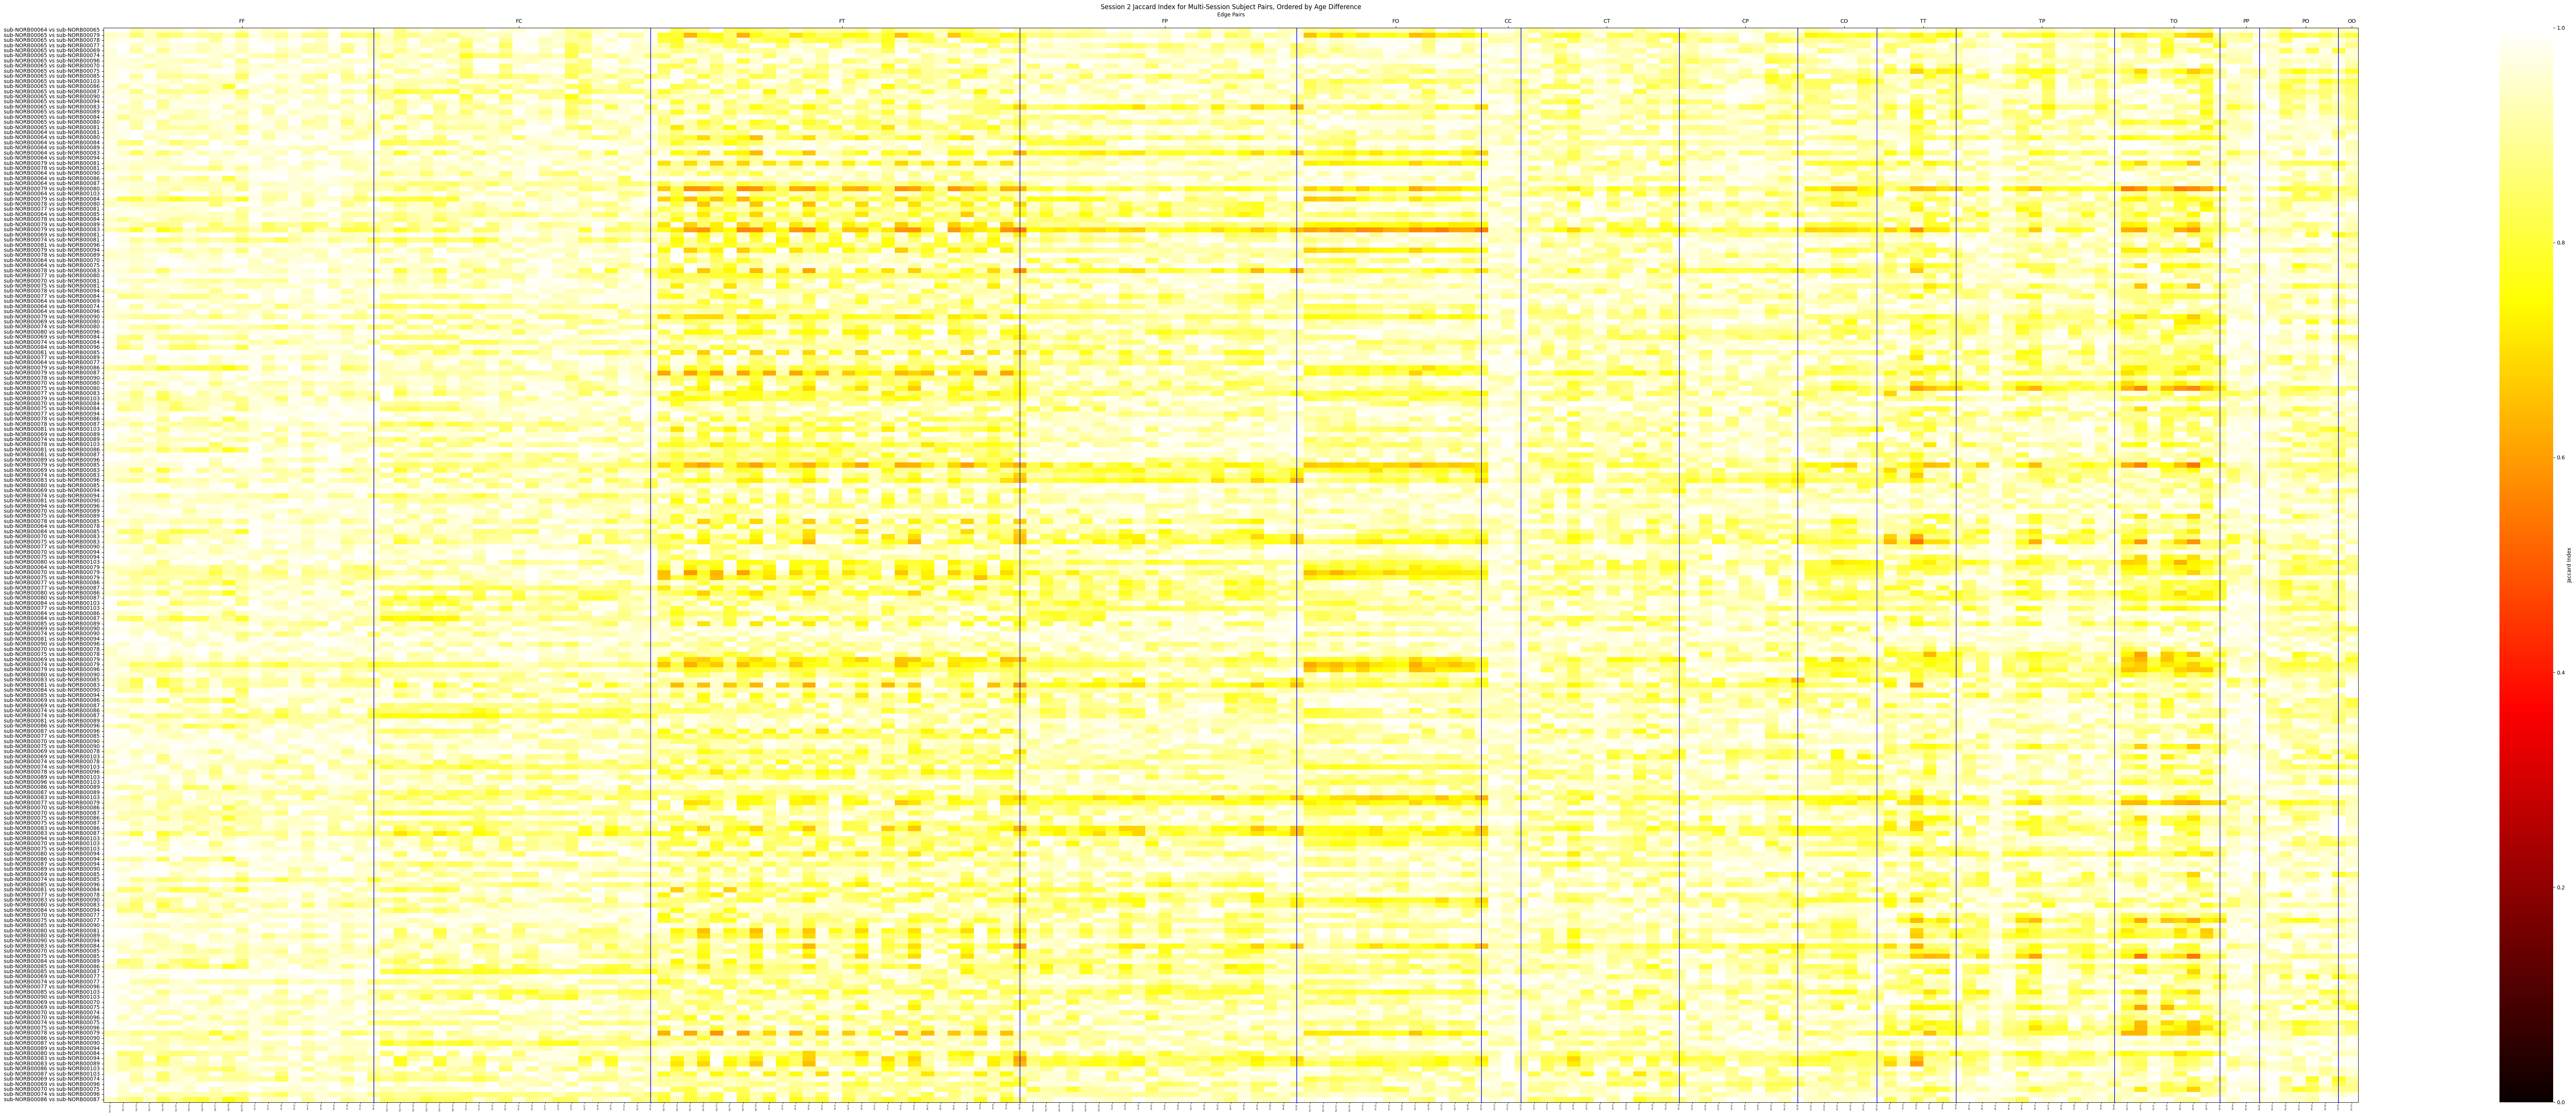

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

age_df = pd.read_csv('age_acq_time_sorted.csv')
age_lookup = dict(zip(age_df['label'], age_df['age_acq_time']))

subject_sessions_dict = defaultdict(list)
for ss in subject_sessions:
    subject_id, session = ss.split('_ses-')
    subject_sessions_dict[subject_id].append(int(session))

multi_session_subjects = [subj for subj, sessions in subject_sessions_dict.items() if len(sessions) > 1]
session2_keys = [f'{subj}_ses-2' for subj in multi_session_subjects]

band_order = 'FCTPO'
order_keys = [a + b for i, a in enumerate(band_order) for b in band_order[i:]]
order_map = {k: i for i, k in enumerate(order_keys)}

def band_key(edge):
    a, b = edge
    return ''.join(sorted((a[0].upper(), b[0].upper()), key=lambda c: band_order.index(c)))

sorted_edge_pairs = sorted(edge_pairs, key=lambda ep: order_map[band_key(ep)])

session2_pairs_by_age = []
for i, ss1 in enumerate(sorted(session2_keys)):
    if ss1 not in subject_sessions or ss1 not in age_lookup:
        continue
    for ss2 in sorted(session2_keys)[i+1:]:
        if ss2 not in subject_sessions or ss2 not in age_lookup:
            continue

        age_diff = abs(age_lookup[ss1] - age_lookup[ss2])
        values = [
            jaccard_indices[edge].get((ss1, ss2), jaccard_indices[edge].get((ss2, ss1), np.nan))
            for edge in sorted_edge_pairs
        ]

        if not np.isnan(values).all():
            session2_pairs_by_age.append({
                'pair_label': f"{ss1.split('_ses-')[0]} vs {ss2.split('_ses-')[0]}",
                'age_difference': age_diff,
                'values': values,
            })

sorted_valid_pairs = sorted(session2_pairs_by_age, key=lambda item: item['age_difference'], reverse=True)

heatmap_df = pd.DataFrame(
    [item['values'] for item in sorted_valid_pairs],
    index=[item['pair_label'] for item in sorted_valid_pairs],
    columns=[f'{a}-{b}' for a, b in sorted_edge_pairs],
)

print(f"\nSession 2 heatmap shape: {heatmap_df.shape}")
if not heatmap_df.empty:
    print(f"Smallest age difference: {sorted_valid_pairs[-1]['age_difference']:.4f}")
    print(f"Largest age difference: {sorted_valid_pairs[0]['age_difference']:.4f}")

fig_width = max(72, len(heatmap_df.columns) * 0.45)
fig_height = max(18, len(heatmap_df.index) * 0.14)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    heatmap_df,
    cmap='hot',
    cbar_kws={'label': 'Jaccard Index'},
    vmin=0,
    vmax=1,
    ax=ax,
    xticklabels=False,
    yticklabels=True,
 )
ax.set_xticks(np.arange(len(heatmap_df.columns)) + 0.5)
ax.set_xticklabels(heatmap_df.columns, rotation=90, fontsize=4)
ax.tick_params(axis='x', which='both', length=2, pad=1)

col_band_keys = [band_key(ep) for ep in sorted_edge_pairs]
unique_band_keys = [k for k in order_keys if k in col_band_keys]

group_positions = []
group_labels = []
group_boundaries = []
for key in unique_band_keys:
    indices = [i for i, k in enumerate(col_band_keys) if k == key]
    if not indices:
        continue
    group_positions.append((indices[0] + indices[-1]) / 2.0 + 0.5)
    group_labels.append(key)
    group_boundaries.append(indices[-1] + 0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(group_positions)
ax_top.set_xticklabels(group_labels, fontsize=10, rotation=0)
ax_top.xaxis.set_ticks_position('top')
ax_top.xaxis.set_label_position('top')
ax_top.set_xlabel('Band Pair')

for bpos in group_boundaries[:-1]:
    ax.axvline(x=bpos, color='blue', linewidth=1.2, zorder=3)

plt.title('Session 2 Jaccard Index for Multi-Session Subject Pairs, Ordered by Age Difference')
plt.xlabel('Edge Pairs')
plt.ylabel('Subject Pairs (sorted by age difference)')
plt.tight_layout()
plt.savefig("jaccard_correlation_session2.png")
plt.show()